# Phase 3 : Modélisation, Optimisation et Interprétabilité avec XGBoost

Ce notebook prend en charge les datasets finaux issus de la phase d'ingénierie des caractéristiques.

## Objectifs de cette phase
- Construire un **Pipeline de prétraitement** robuste (imputation et encodage).
- Définir une **métrique de Coût Métier** sur-mesure (pénalisant lourdement les Faux Négatifs).
- Entraîner un modèle **XGBoost de référence** (Baseline) séquentiellement pour préserver la mémoire.
- Lancer une **Optimisation des Hyperparamètres** (`RandomizedSearchCV`) pour minimiser le coût financier.
- Sauvegarder le modèle optimisé pour le Dashboard Streamlit.
- Expliquer les décisions de l'algorithme avec **SHAP** (Summary Plot & Waterfall Plot).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time
import os
import joblib
warnings.filterwarnings('ignore')

# Scikit-Learn & XGBoost
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Interprétabilité
import shap

## 1. Chargement des données et Préparation du Pipeline

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Chargement du dataset d'entraînement final...")
train_final = pd.read_csv(DATA_PROCESSED / "train_final.csv")

# Séparation de la cible (y) et des variables (X)
X = train_final.drop(columns=['TARGET', 'SK_ID_CURR'])
y = train_final['TARGET']

# Identification automatique des types de colonnes
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Création des transformateurs
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) 
])

# Assemblage du préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Création du jeu d'évaluation local (Hold-out test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test : {X_test.shape}")

Chargement du dataset d'entraînement final...
Dimensions de X_train : (246008, 176)
Dimensions de X_test : (61503, 176)


## 2. Définition de la métrique métier (Business Cost)

L'objectif de la banque est de minimiser ses pertes financières.
- **Faux Négatif (FN)** : On prête à un profil à risque. Coût = 10.
- **Faux Positif (FP)** : On refuse un bon client. Coût = 1.

In [3]:
def custom_business_cost(y_true, y_pred):
    """Calcule le coût financier moyen par prédiction."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    
    cost_fn = 10  
    cost_fp = 1   
    
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    return total_cost / len(y_true)

# greater_is_better=False indique à Scikit-Learn qu'il faut minimiser ce score
business_scorer = make_scorer(custom_business_cost, greater_is_better=False)

## 3. Entraînement du modèle XGBoost (Baseline)

In [4]:
# Calcul du ratio de déséquilibre pour XGBoost
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Ratio de déséquilibre des classes calculé : {ratio:.2f}")

# Création du pipeline baseline
xgb_baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=ratio, 
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nLancement de la validation croisée séquentielle (Baseline)...")
cv_results = cross_validate(
    xgb_baseline_pipeline, X_train, y_train, cv=cv_strategy, 
    scoring={'business_cost': business_scorer, 'roc_auc': 'roc_auc'},
    n_jobs=1 # Séquentiel pour protéger la RAM
)

print(f"Baseline - ROC-AUC moyen : {np.mean(cv_results['test_roc_auc']):.4f}")
print(f"Baseline - Coût Métier moyen : {np.abs(np.mean(cv_results['test_business_cost'])):.4f}")

Ratio de déséquilibre des classes calculé : 11.39

Lancement de la validation croisée séquentielle (Baseline)...
Baseline - ROC-AUC moyen : 0.7601
Baseline - Coût Métier moyen : 0.5274


## 4. Optimisation des Hyperparamètres (RandomizedSearchCV)
Recherche de la meilleure configuration d'arbres pour faire baisser le coût métier.

In [5]:
print("Configuration de la grille de recherche...")

param_distributions = {
    'classifier__max_depth': [3, 4, 5], # Limite la profondeur pour éviter l'overfitting
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__colsample_bytree': [0.5, 0.7, 0.9], 
    'classifier__subsample': [0.5, 0.7, 0.9] 
}

random_search = RandomizedSearchCV(
    estimator=xgb_baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=10, 
    scoring=business_scorer, 
    cv=3, # 3 plis pour gagner du temps
    verbose=1,
    random_state=42,
    n_jobs=1 
)

print("\n🚀 Lancement de l'optimisation...")
start_time = time.time()
random_search.fit(X_train, y_train)
print(f"\n✅ Optimisation terminée en {(time.time() - start_time) / 60:.2f} minutes.")

print("\n--- Meilleurs Hyperparamètres trouvés ---")
print(random_search.best_params_)
print(f"Nouveau Coût Métier moyen (CV) : {np.abs(random_search.best_score_):.4f}")

# Extraction du meilleur pipeline
best_xgb_pipeline = random_search.best_estimator_

Configuration de la grille de recherche...

🚀 Lancement de l'optimisation...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Optimisation terminée en 17.55 minutes.

--- Meilleurs Hyperparamètres trouvés ---
{'classifier__subsample': 0.9, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.7}
Nouveau Coût Métier moyen (CV) : 0.5076


## 5. Évaluation Finale et Sauvegarde pour Streamlit


--- Rapport de Classification (Jeu de Test - Modèle Optimisé) ---
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.18      0.70      0.28      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.71      0.55     61503
weighted avg       0.90      0.71      0.78     61503


 Simulation financière : Pénalité totale = 31,077 points.


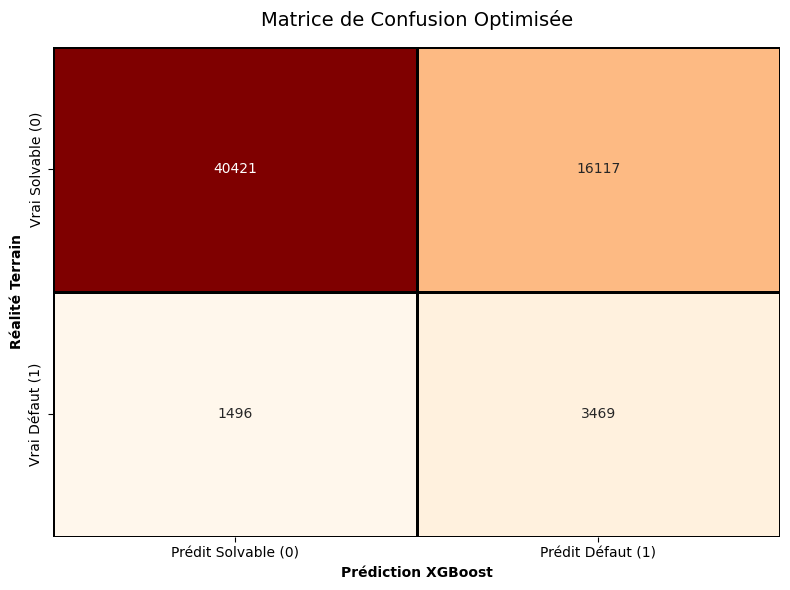


Sauvegarde du modèle et des données pour le Dashboard Streamlit...
 Modèle optimisé sauvegardé dans 'models/xgboost_baseline.pkl'


In [8]:
# Prédictions du MEILLEUR modèle sur le jeu de test
y_pred_opt = best_xgb_pipeline.predict(X_test)

print("\n--- Rapport de Classification (Jeu de Test - Modèle Optimisé) ---")
print(classification_report(y_test, y_pred_opt))

cm = confusion_matrix(y_test, y_pred_opt)
cost_test = custom_business_cost(y_test, y_pred_opt) * len(y_test)

print(f"\n Simulation financière : Pénalité totale = {cost_test:,.0f} points.")

# Visualisation Gestalt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False,
            xticklabels=['Prédit Solvable (0)', 'Prédit Défaut (1)'], 
            yticklabels=['Vrai Solvable (0)', 'Vrai Défaut (1)'],
            linewidths=1, linecolor='black')
plt.title('Matrice de Confusion Optimisée', fontsize=14, pad=15)
plt.ylabel('Réalité Terrain', fontweight='bold')
plt.xlabel('Prédiction XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

# --- SAUVEGARDE ---
print("\nSauvegarde du modèle et des données pour le Dashboard Streamlit...")
os.makedirs(PROJECT_ROOT / "models", exist_ok=True)

# On écrase l'ancien modèle par le modèle optimisé pour que le Dashboard l'utilise automatiquement
joblib.dump(best_xgb_pipeline, PROJECT_ROOT / "models" / "xgboost_baseline.pkl")

test_sample = X_test.copy()
test_sample['TARGET'] = y_test
test_sample.to_csv(DATA_PROCESSED / "test_sample_dashboard.csv", index=False)

print(" Modèle optimisé sauvegardé dans 'models/xgboost_baseline.pkl'")

## 6. Interprétabilité du Modèle (SHAP)
Ouverture de la boîte noire pour justifier les décisions d'octroi de crédit.

Préparation des données pour SHAP (Modèle Optimisé)...
Calcul des valeurs de Shapley...

--- 1. Interprétabilité Globale (Politique de la Banque) ---


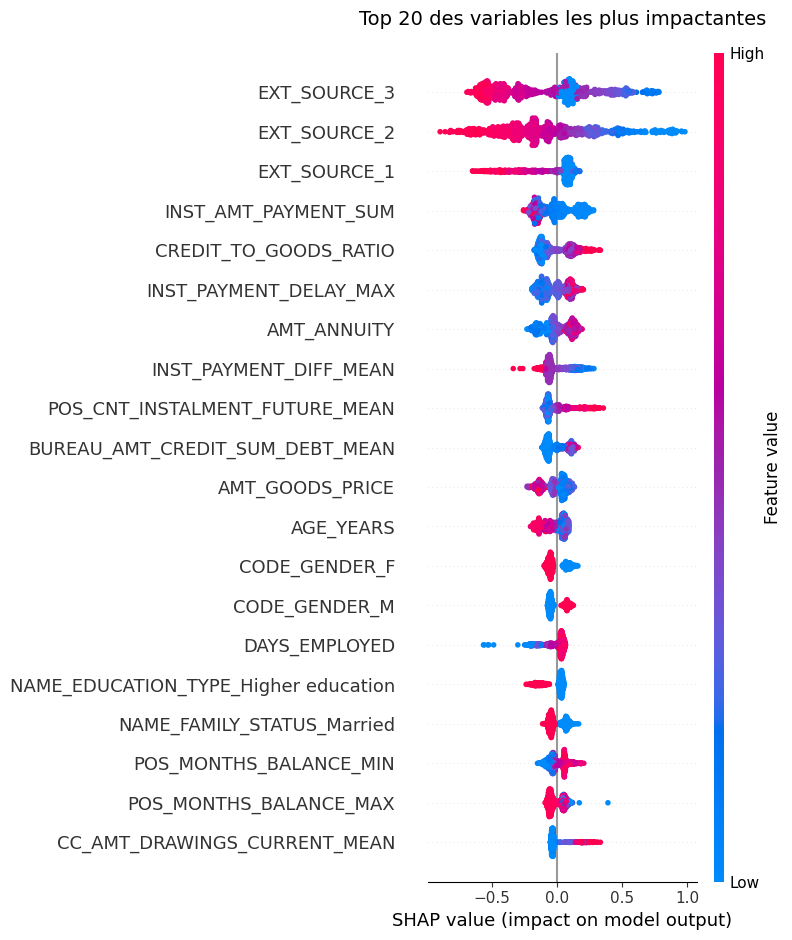


--- 2. Interprétabilité Locale (Client n°42) ---


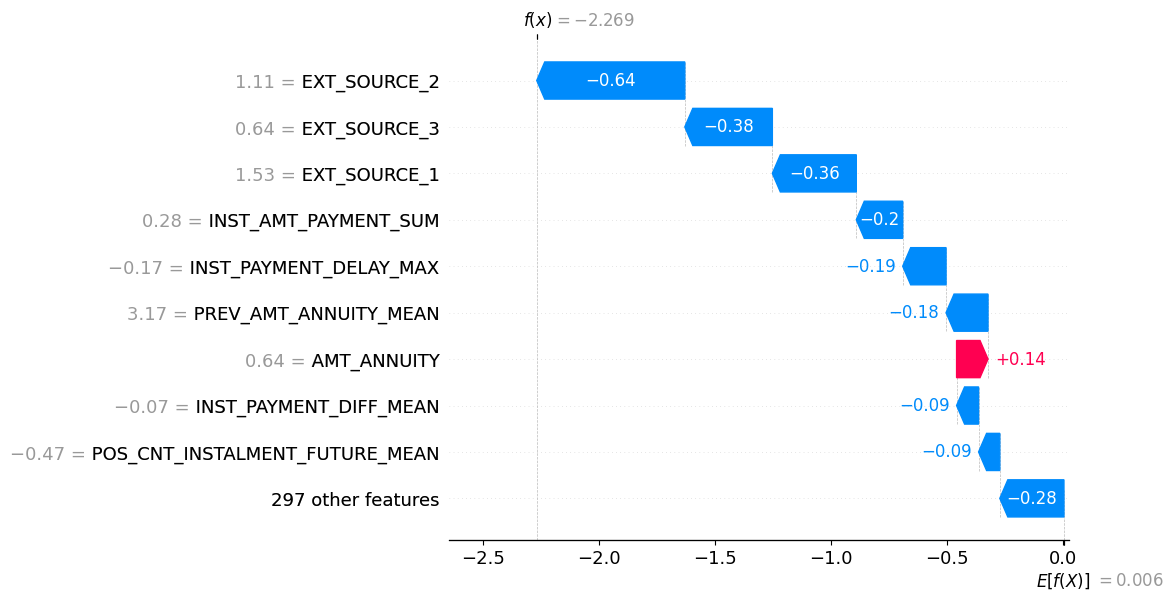

<Figure size 640x480 with 0 Axes>

In [9]:
print("Préparation des données pour SHAP (Modèle Optimisé)...")

# 1. Extraction depuis le pipeline optimisé
preprocessor_opt = best_xgb_pipeline.named_steps['preprocessor']
xgb_model_opt = best_xgb_pipeline.named_steps['classifier']

# 2. Transformation
X_test_transformed = preprocessor_opt.transform(X_test)
ohe_feature_names = preprocessor_opt.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(ohe_feature_names)

df_test_transformed = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# 3. Échantillonnage (1000 lignes)
df_sample = df_test_transformed.sample(n=1000, random_state=42)

# 4. Calcul Shapley
print("Calcul des valeurs de Shapley...")
explainer = shap.TreeExplainer(xgb_model_opt)
shap_values = explainer.shap_values(df_sample)

# --- A. Interprétabilité GLOBALE ---
print("\n--- 1. Interprétabilité Globale (Politique de la Banque) ---")
plt.figure(figsize=(10, 6))
plt.title("Top 20 des variables les plus impactantes", fontsize=14, pad=20)
shap.summary_plot(shap_values, df_sample, max_display=20, show=False)
plt.tight_layout()
plt.show()

# --- B. Interprétabilité LOCALE ---
client_index = 42  
print(f"\n--- 2. Interprétabilité Locale (Client n°{client_index}) ---")

# Formatage propre pour le Waterfall Plot
df_display = df_sample.round(2)
shap_val_client = shap.Explanation(
    values=shap_values[client_index],
    base_values=explainer.expected_value,
    data=df_display.iloc[client_index],
    feature_names=df_display.columns
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_val_client, max_display=10)
plt.tight_layout()
plt.show()